# Finding Common Traits Between People Who Do or Do Not Volunteer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Volunteer Segments

We will start this segment analysis on the subset of the processed data that is identified as volunteers.

In [2]:
df_v = pd.read_csv('../data/processed/cev_volunteers.csv')

In [3]:
df_v.head()

,hrnumhou,supwgt,hubus_YES,gtmetsta_NONMETROPOLITAN,pesex_MALE,veteran_Yes,pehspnon_NON-HISPANIC,disability_Yes,action_Yes,meeting_Yes,...,citizen_type_Citizen,citizen_type_Naturalized,citizen_type_Non,work_status_Employed,work_status_Not Working,work_status_Unemployed,housing_unit_House,housing_unit_Mobile,housing_unit_Other,housing_unit_Unit
0,2,2743.1032,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,1,0,0,0
1,5,3734.6711,0,0,1,0,1,0,0,0,...,1,0,0,1,0,0,1,0,0,0
2,5,3619.4642,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,1,0,0,0
3,4,3063.2525,0,0,1,0,1,0,1,0,...,1,0,0,1,0,0,1,0,0,0
4,4,3411.9942,0,0,0,0,1,0,1,0,...,1,0,0,0,1,0,1,0,0,0


In [4]:
df_v.shape

(13724, 57)

The purpose of this analysis is exploratory in nature, so the weights for these entries will left out during the process of scaling, applying PCA, and modeling We will revisit them for profiling after the model is made.

In [5]:
df_features = df_v.drop(columns=['supwgt'])

### Feature Scaling

I will be using a StandardScaler from sklearn on this dataset prior to performing PCA so that principal component vecotrs are not influenced by the varying scales present in our features.

In [6]:
scaler = StandardScaler()

In [7]:
df_scaled = scaler.fit_transform(df_features)

### Dimensionality Reduction & Principal Component Analysis

I will use sklearn's PCA class to perform principal component analysis on the datain order to find the vectors of maximal variance in the data. To start, I will not set any parameters so all components are computed.
Then I will visualize the individual component ratios of variance and cumulative variance explained to try and find an ideal number of components we can reduce our data down to while maintaining reasonable variance.
Once I've made a choice for the number of components to keep, I will re-fit a PCA instance to perform the decided-on transformation.

In [8]:
pca = PCA()

In [9]:
pca.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

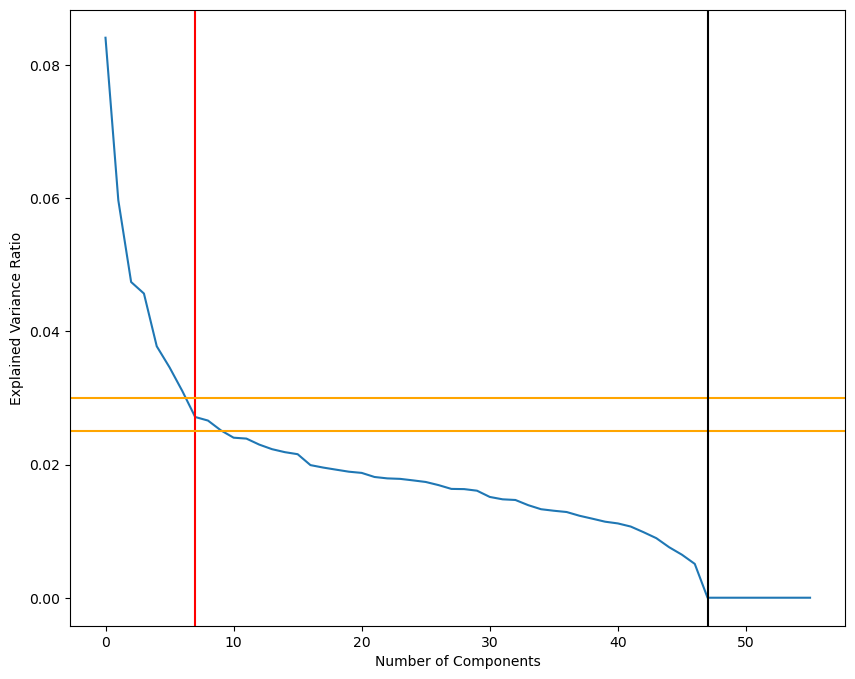

In [10]:
fig = plt.figure(figsize=(10,8))
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.axvline(x=7, c='red')
plt.axhline(y=0.03, c='orange')
plt.axhline(y=0.025, c='orange')
plt.axvline(x=47, c='black')
plt.show();

Elbow for this graphs occurs at ~ 7 components, variance ratio somewhere between 0.025 and 0.03. Components past 46 offer no variance.

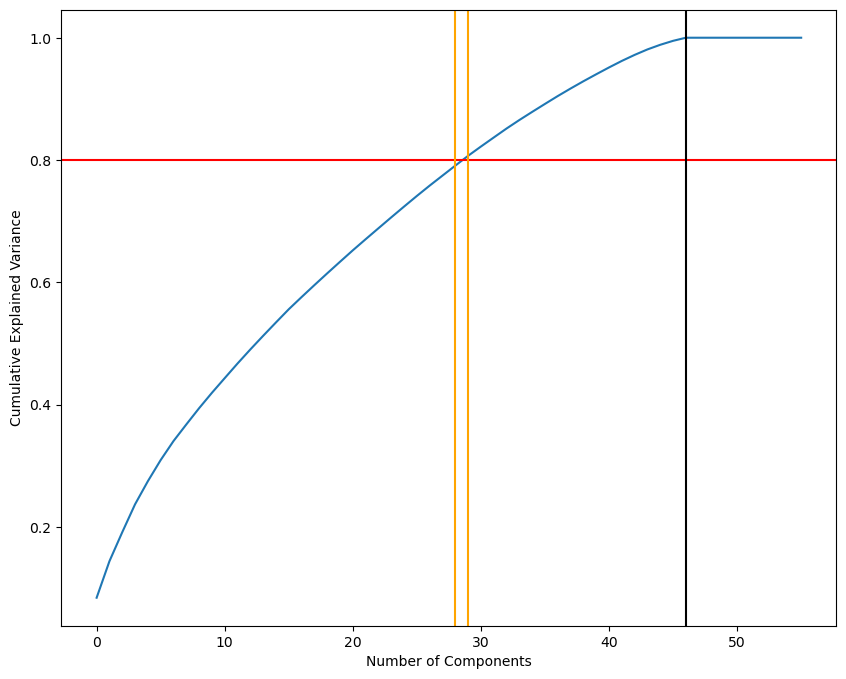

In [11]:
figure = plt.figure(figsize=(10,8))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.8, c='red')
plt.axvline(x=28, c='orange')
plt.axvline(x=29, c='orange')
plt.axvline(x=46, c='black')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show();

80% of cumulative variance is explained by ~29 components. 100% of cumulative variance explained by 46 components.

With these results, I will move forward with a PCA object using 29 components.

In [12]:
pca = PCA(n_components = 29)
df_pca = pca.fit_transform(df_scaled)

Now we can look at the resulting components and get a sense of some groups that may have formed. I will write a function to do this so I can use it on multiple components, inlcuding in the nonvolunteer section, while saving code space.

I will look at the first 7 components, since that's where the elbow in our explained variance ratio graph occurred.

In [13]:
def get_weights(s_pca, component_num, col_list):
    col_name = 'PC_'+str(component_num + 1)
    
    pca_weights = pd.DataFrame(
        s_pca.components_[component_num].T,  
        index=col_list,
        columns=[col_name]
    )
    
    # Print the top 10 features associated with the principal component, sorted by absolute value of weight
    print("Top positive:")
    print(pca_weights.sort_values(by=col_name, ascending=False).head(10))
    print("\nTop negative:")
    print(pca_weights.sort_values(by=col_name, ascending=True).head(10))
    print('----------------------------------------------------------')
    
    return pca_weights

In [14]:
col_list = df_features.columns

In [15]:
for pc in range(7):
    get_weights(pca, pc, col_list)

Top positive:
                      PC_1
voterstatus_Yes   0.276473
age_encoded       0.255863
hetenure_Owned    0.245084
ntalk_encoded     0.224342
nissues_encoded   0.217398
favors_encoded    0.202352
news_encoded      0.183634
ffissues_encoded  0.182883
donate_Yes        0.180291
contact_Yes       0.178578

Top negative:
                              PC_1
hetenure_Rented          -0.245826
voterstatus_No           -0.240292
pemaritl_NEVER MARRIED   -0.213978
citizen_type_Non         -0.152796
voterstatus_NA           -0.122321
work_status_Employed     -0.121054
simrace_Black            -0.104588
simrace_Asian            -0.100702
citizen_type_Naturalized -0.073065
hrnumhou                 -0.052224
----------------------------------------------------------
Top positive:
                              PC_2
work_status_Employed      0.379303
hhincome_encoded          0.359455
hrnumhou                  0.280860
pemaritl_MARRIED          0.254981
ed_level_encoded          0.213600
hubus_

Let's tabulate this information to be easier to read:

| Component_Num | Positively-Pointed Features | Negatively-Pointed Features |
| ------------- | --------------------------- | --------------------------- |
| 1 | local voter, age, homeowner, interactions w/ neighbors, news consumption, donates non-politically, contacts politicians | renter, inelligible or non-local voter, never married, non-citizen or naturalized, employed, black or asian, household size |
| 2 | employed, income, married, education level, business owner, lives in a house, asian, homeowner, naturalized | not working, age, widowed, disabled, lives in mobile home, divorced, citizen, metro/non-metro, renter, veteran |
| 3 | citizen, white, homeowner, midwestern, married, metro/non-metro, non-local voter, household size, hispanic/non-hispanic, income | asian or black, naturalized or non-citizen, talking w/ neighbors/family/friends about issues, sharing views online, engages with local issues |
| 4 | citizen, never married or divorced, renter, employed, talking w/ family/friends about issues, participated in a boycott, contacts politicians, sharing views online, local voter | married, homeowner, naturalized or non-citizen, not working, asian, age, household size, inelligible or non-local voter |
| 5 | lives in a house, local voter, education level, age, not working, news consumption, hispanic/non-hispanic, widowed, black or asian | lives in a mobile home, interactions with neighbors, engages with local issues, household size, non-local voter, metro/non-metro, business owner, white |
| 6 | lives in a house, white, interactions with neighbors, non-local voter, renter, midwestern, engages with local issues, talking with family/friends | lives in a mobile home, black or asian, local voter, southern, homeowner, education level, hispanic/non-hispanic, naturalized, donates politically |
| 7 | southern, black, interactions with neighbors, hispanic/non-hispanic, citizen, engages with local issues, lives in a house, non-local voter | western or northeastern, white, participated in a boycott, lives in a mobile home, naturalized or non-citizen, local voter, contacts politicians, renter |

### Clustering

In [16]:
clusters = range(2, 20)
inertias = {}
silhouette_scores = {}

for k in clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    
    # Store metrics
    inertias[k] = kmeans.inertia_
    score = silhouette_score(df_pca, kmeans.labels_)
    silhouette_scores[k] = score
    print(f"k={k} | Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {score:.3f}")

k=2 | Inertia: 554052.47 | Silhouette Score: 0.128
k=3 | Inertia: 525326.23 | Silhouette Score: 0.066
k=4 | Inertia: 509121.79 | Silhouette Score: 0.060
k=5 | Inertia: 484550.83 | Silhouette Score: 0.077
k=6 | Inertia: 476487.89 | Silhouette Score: 0.059
k=7 | Inertia: 467004.79 | Silhouette Score: 0.052
k=8 | Inertia: 443009.02 | Silhouette Score: 0.055
k=9 | Inertia: 428085.85 | Silhouette Score: 0.065
k=10 | Inertia: 415677.18 | Silhouette Score: 0.066
k=11 | Inertia: 406903.78 | Silhouette Score: 0.071
k=12 | Inertia: 398412.26 | Silhouette Score: 0.072
k=13 | Inertia: 387150.76 | Silhouette Score: 0.069
k=14 | Inertia: 384452.27 | Silhouette Score: 0.073
k=15 | Inertia: 377818.49 | Silhouette Score: 0.073
k=16 | Inertia: 368734.34 | Silhouette Score: 0.077
k=17 | Inertia: 355507.01 | Silhouette Score: 0.079
k=18 | Inertia: 342798.00 | Silhouette Score: 0.086
k=19 | Inertia: 339118.43 | Silhouette Score: 0.074


In [17]:
score_diff = {}

for s in inertias.keys():
    try:
        score_diff[s] = inertias[s] - inertias[s+1]
    except KeyError:
        score_diff[s] = 0

In [18]:
inertia_lists = sorted(inertias.items())
sil_score_lists = sorted(silhouette_scores.items())
diff_lists = sorted(score_diff.items())

x1, y1 = zip(*inertia_lists)
x2, y2 = zip(*diff_lists)
x3, y3 = zip(*sil_score_lists)

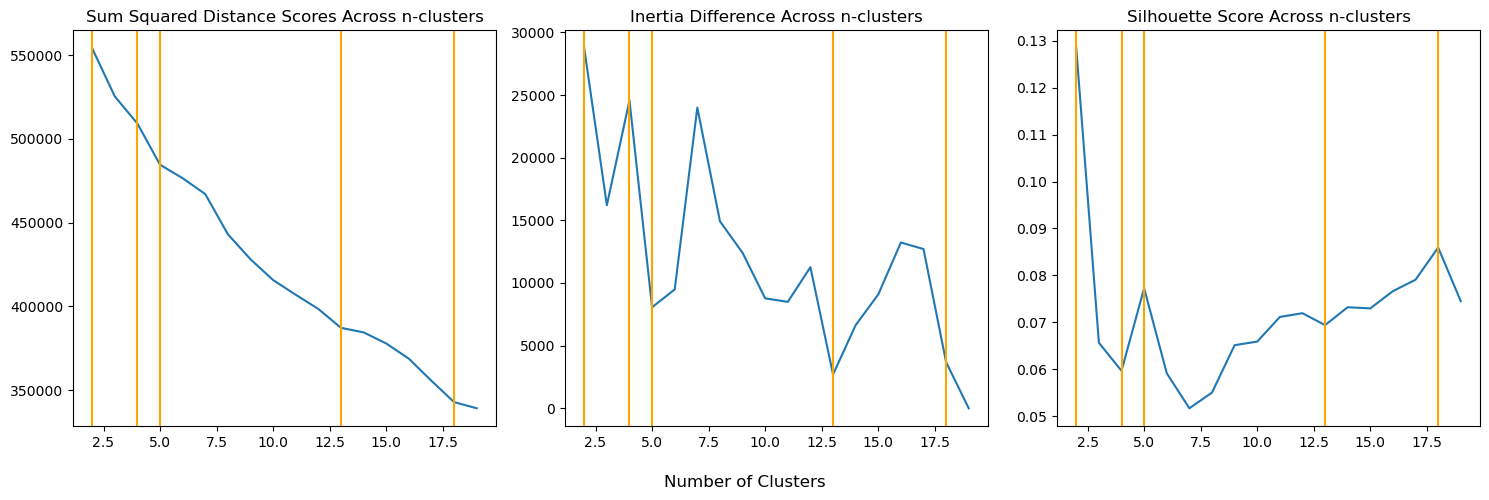

In [19]:
fig, (ax, bx, cx) = plt.subplots(1,3, figsize=(15,5))
fig.supxlabel('Number of Clusters')
ax.set_title('Sum Squared Distance Scores Across n-clusters')
bx.set_title('Inertia Difference Across n-clusters')
cx.set_title('Silhouette Score Across n-clusters')

ax.plot(x1, y1)
bx.plot(x2, y2)
cx.plot(x3, y3)

ax.axvline(x=2, c='orange')
ax.axvline(x=4, c='orange')
ax.axvline(x=5, c='orange')
ax.axvline(x=13, c='orange')
ax.axvline(x=18, c='orange')

bx.axvline(x=2, c='orange')
bx.axvline(x=4, c='orange')
bx.axvline(x=5, c='orange')
bx.axvline(x=13, c='orange')
bx.axvline(x=18, c='orange')

cx.axvline(x=2, c='orange')
cx.axvline(x=4, c='orange')
cx.axvline(x=5, c='orange')
cx.axvline(x=13, c='orange')
cx.axvline(x=18, c='orange')

plt.tight_layout()
plt.show()

There's a bit of an elbow at 5 clusters on the sum squared distance scores plot but it is not a dramatic plot by any means. The inertia difference plot is chaotic, but somewhere in the realm of 4-5 clusters seems to be a general inflection point. 2 clusters offers the highest silhouette score, and also the highest inertia value, followed by 18 clusters. Let's look at how the clusters profile with their provided weights before choosing and conducting segment analysis.

In [20]:
def profile_col(df, k):
    for c in k:
        km_model = KMeans(n_clusters=c, random_state=42)
        clusters = km_model.fit_predict(df_pca)
        col = str(c) + 'cluster'
        df[col] = clusters
        cluster_weights = df.groupby(col)['supwgt'].sum()
        cluster_share = cluster_weights / cluster_weights.sum()
        idx = 0
        print(f"k={c}")
        for n in cluster_share:
            print(f"cluster {idx+1}: {n*100:.1f}%")
            idx+=1
        print("-----------------------------")
        df.drop(columns=[col], inplace=True)

In [21]:
profile_col(df_v, [2, 4, 5, 18])

k=2
cluster 1: 44.2%
cluster 2: 55.8%
-----------------------------
k=4
cluster 1: 26.2%
cluster 2: 20.3%
cluster 3: 19.7%
cluster 4: 33.7%
-----------------------------
k=5
cluster 1: 1.9%
cluster 2: 20.6%
cluster 3: 10.0%
cluster 4: 39.1%
cluster 5: 28.5%
-----------------------------
k=18
cluster 1: 3.6%
cluster 2: 6.3%
cluster 3: 7.8%
cluster 4: 2.2%
cluster 5: 14.8%
cluster 6: 3.8%
cluster 7: 9.3%
cluster 8: 3.2%
cluster 9: 6.6%
cluster 10: 0.3%
cluster 11: 8.4%
cluster 12: 5.8%
cluster 13: 4.5%
cluster 14: 11.0%
cluster 15: 9.5%
cluster 16: 1.8%
cluster 17: 0.1%
cluster 18: 0.8%
-----------------------------


With k=2, we have pretty even clusters, and this k value has the highest silhouette score of all options tested, which indicates it has fewer points sharing borders / overlapping with other clusters.

k=4 shows a spread of reasonably sized and distinct clusters, while this has a lower silhouette score it might offer more insight in the context of segments.

When k=5, we see one of the clusters is very small, with it holding 1.9% of the relevant population results. More dramatic and similar results show up in k=12 and 18.

With these results, we'll move forward with k=4.

In [22]:
km_model = KMeans(n_clusters=4, random_state=42)
volunteers = km_model.fit_predict(df_pca)

In [23]:
df_v['cluster'] = volunteers

Let's bring back the profiling results to see how prevelant each cluster is in the volunteer population.

In [24]:
cluster_weights = df_v.groupby('cluster')['supwgt'].sum()

In [25]:
cluster_share = cluster_weights / cluster_weights.sum()

In [26]:
cluster_labels = [1, 2, 3, 4]
cluster_colors = ['tab:red', 'tab:blue', 'tab:orange', 'tab:green']

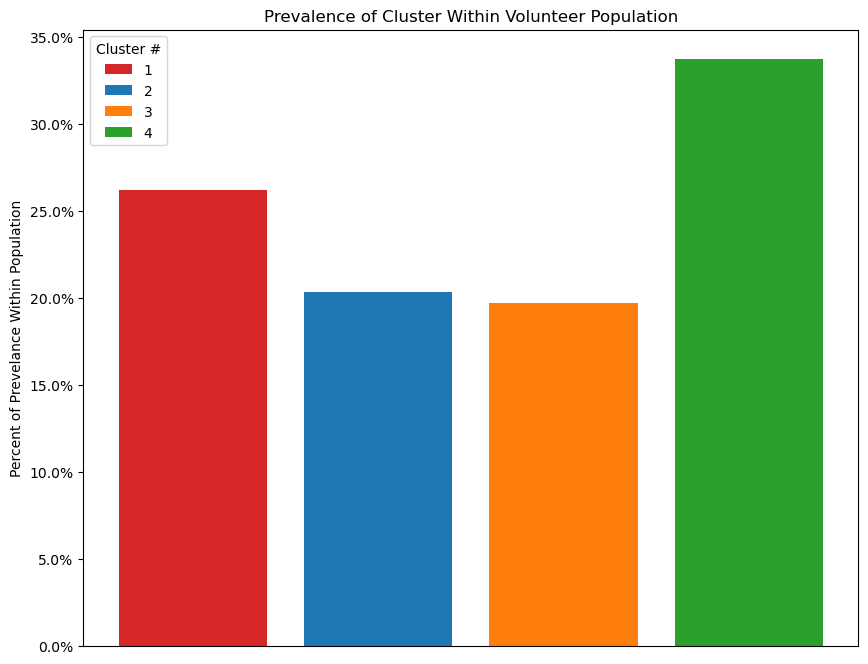

In [27]:
fig, ax = plt.subplots(figsize=(10,8))

ax.bar(cluster_labels, cluster_share, label=cluster_labels, color=cluster_colors)
ax.set_title('Prevalence of Cluster Within Volunteer Population')
ax.set_ylabel('Percent of Prevelance Within Population')
ax.legend(title='Cluster #')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xticks([])

plt.show()

This shows that, using the provided nonresponse weight, in the volunteer population the traits that direct clusters 4 and 1 are most prevalent, and those in clusters 2 and 3 are least prevalent but still sizable. Now let's see what those traits are for each cluster:

In [28]:
centroids = km_model.cluster_centers_

In [29]:
centroids_scaled = pca.inverse_transform(centroids)

In [30]:
centroids_df = pd.DataFrame(centroids_scaled, columns=col_list)

In [31]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=False).head(10)}\n")

cluster 1:
voterstatus_No              0.896360
hetenure_Owned              0.470019
hrnumhou                    0.399447
simrace_Asian               0.378761
citizen_type_Naturalized    0.365438
work_status_Employed        0.283651
citizen_type_Non            0.247777
pemaritl_NEVER MARRIED      0.228219
voterstatus_NA              0.198449
housing_unit_Mobile         0.174718
Name: 0, dtype: float64

cluster 2:
work_status_Not Working    1.270575
age_encoded                1.028411
pemaritl_WIDOWED           0.517996
ntalk_encoded              0.380824
disability_Yes             0.380231
news_encoded               0.347096
hetenure_Owned             0.342447
voterstatus_Yes            0.334044
org_Yes                    0.286609
veteran_Yes                0.274870
Name: 1, dtype: float64

cluster 3:
hetenure_Rented           1.969435
pemaritl_NEVER MARRIED    0.820309
voterstatus_No            0.411898
citizen_type_Non          0.405469
simrace_Black             0.368606
work_status_

In [32]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=True).head(10)}\n")

cluster 1:
voterstatus_Yes        -0.939809
news_encoded           -0.522341
ffissues_encoded       -0.509679
age_encoded            -0.497026
hetenure_Rented        -0.469906
nissues_encoded        -0.453401
citizen_type_Citizen   -0.449632
ntalk_encoded          -0.411654
contact_Yes            -0.398093
donate_Yes             -0.375205
Name: 0, dtype: float64

cluster 2:
work_status_Employed     -1.240601
hrnumhou                 -0.520022
hhincome_encoded         -0.432865
hubus_YES                -0.377752
pemaritl_NEVER MARRIED   -0.359967
hetenure_Rented          -0.351191
voterstatus_No           -0.301923
citizen_type_Non         -0.190201
ed_level_encoded         -0.155956
simrace_Asian            -0.132926
Name: 1, dtype: float64

cluster 3:
hetenure_Owned            -1.941268
age_encoded               -0.758027
pemaritl_MARRIED          -0.683643
hhincome_encoded          -0.625822
voterstatus_Yes           -0.482350
simrace_White             -0.422436
ntalk_encoded        

### Analysis

Summarizing the above information:

| Cluster | Above-Average Features | Below-Average Features |
| ------------- | --------------------------- | --------------------------- |
| 1 | non-local or ineligble voter, homeowner, household size, Asian, naturalized or non-citizen, employed, never married, lives in a mobile home | local voter, news consumption, discusses issues friend/family/neighbors, age, renter, citizen, talks to neighbors, contacts politicians, donates non-politically |
| 2 | not working, age, widowed, talks to neighbors, disabled, news consumption, homeowner, local voter, belongs to organization(s), veteran | employed, household size, income, business owner, never married, renter, non-local voter, non-citizen, education level, Asian |
| 3 | renter, seperated or never married, non-local or ineligible voter, non-citizen, Black or Biracial, employed or unemployed | homeowner, age, married, income, local voter, White, talk to and does favors for neighbors, donates non-politically, not working |
| 4 | employed, income, local voter, homeowner, business owner, education level, married, discusses issues with friends/family, engages with local issues, household size | not working, non-local voter, renter, never married or widowed, disabled, non-citizen, Asian or Black, age |

I'm going to focus in on the features that pull points closer to the centroids of each cluster, the "above-average features". I'll be looking at a lot of columns in different clusters, so I'll use the below function to quickly print the information I want.

In [33]:
def cluster_exp(dataframe, cluster_idx, columns):
    for c in columns:
        print(f"{c}:\n")
        print(dataframe[dataframe['cluster'] == cluster_idx][c].describe())
        print('\n')
        print(dataframe[dataframe['cluster'] == cluster_idx][c].value_counts())
        print('----------------------------------------------')

A reminder that all individuals in this subset of data answered that they had volunteered in some capacity in the last 12 months.

#### Cluster 1 Exploration

In [34]:
cluster_exp(df_v, 0, centroids_df.iloc[0].sort_values(ascending=False).head(10).index)

voterstatus_No:

count    2831.000000
mean        0.648534
std         0.477512
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: voterstatus_No, dtype: float64


voterstatus_No
1    1836
0     995
Name: count, dtype: int64
----------------------------------------------
hetenure_Owned:

count    2831.000000
mean        0.989403
std         0.102413
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: hetenure_Owned, dtype: float64


hetenure_Owned
1    2801
0      30
Name: count, dtype: int64
----------------------------------------------
hrnumhou:

count    2831.000000
mean        3.100671
std         1.491591
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        13.000000
Name: hrnumhou, dtype: float64


hrnumhou
2     854
4     630
3     535
1     342
5     302
6     118
7      34
8       9
10      2
9       2
13      2
11   

Within this cluster, the above average outcomes show individuals that:

- Are not active in local elections even if they are eligible to participate,
- Own their homes,
- Have 1-4 people in their home,
- Are not solely Asian by race,
- Are native citizens,
- Are employed,
- Have been married at some point, and
- Do not live in a mobile home

This sounds like a pretty stereotypical American household containing a small, working family in a static home that only votes during big elections.

#### Cluster 2 Exploration

In [35]:
cluster_exp(df_v, 1, centroids_df.iloc[1].sort_values(ascending=False).head(10).index)

work_status_Not Working:

count    3764.000000
mean        0.965197
std         0.183306
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: work_status_Not Working, dtype: float64


work_status_Not Working
1    3633
0     131
Name: count, dtype: int64
----------------------------------------------
age_encoded:

count    3764.000000
mean        6.092986
std         1.112280
min         1.000000
25%         6.000000
50%         6.000000
75%         7.000000
max         8.000000
Name: age_encoded, dtype: float64


age_encoded
6    1595
7    1161
5     542
8     215
4     109
3     100
2      29
1      13
Name: count, dtype: int64
----------------------------------------------
pemaritl_WIDOWED:

count    3764.000000
mean        0.194208
std         0.395643
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: pemaritl_WIDOWED, dtype: float64


pemaritl_WIDOWED
0    3033
1  

Within this cluster, the above average outcomes show individuals that:

- Are not working,
- Are in their mid-60s to mid 80s which is commonly a retiree age range,
- Are not widowed,
- Talk or spend time with their neighbors a few times a month,
- Are not disabled,
- Consume news about political, societal, or local issues basically every day,
- Own their home,
- Vote in local elections,
- Belong to at least one group, organization, or association, and
- Are not military veterans

This group paints a picture of the locally engaged, established, retiree who engages socially by being friendly with their neighbors or participating in group activities.

#### Cluster 3 Exploration

In [36]:
cluster_exp(df_v, 2, centroids_df.iloc[2].sort_values(ascending=False).head(10).index)

hetenure_Rented:

count    2341.000000
mean        0.979069
std         0.143185
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: hetenure_Rented, dtype: float64


hetenure_Rented
1    2292
0      49
Name: count, dtype: int64
----------------------------------------------
pemaritl_NEVER MARRIED:

count    2341.000000
mean        0.500641
std         0.500106
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: pemaritl_NEVER MARRIED, dtype: float64


pemaritl_NEVER MARRIED
1    1172
0    1169
Name: count, dtype: int64
----------------------------------------------
voterstatus_No:

count    2341.000000
mean        0.436138
std         0.496011
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: voterstatus_No, dtype: float64


voterstatus_No
0    1320
1    1021
Name: count, dtype: int64
------------------------

Within this cluster, the above average outcomes show individuals that:

- Rent their homes,
- Are citizens,
- Are eligible voters that lean slightly towards not participating in local elections,
- Almost exactly 50/50 on ever being married, but not currently seperated,
- Are not solely Black nor Biracial by race,
- Are native citizens, and
- Are employed,

This group is a little hard to parse, it is the first primarily non-homeowner group but they fall in the middle in a couple of items such as local election participation and marriage status. These are working people who haven't hit certain milestones such has home ownership or marriage, and they don't inherently participate in local happenings. I find it interesting that certain class predictors, such as income or age, are so low on the scale for this group.

#### Cluster 4 Exploration

In [37]:
cluster_exp(df_v, 3, centroids_df.iloc[3].sort_values(ascending=False).head(10).index)

work_status_Employed:

count    4788.000000
mean        0.969298
std         0.172526
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: work_status_Employed, dtype: float64


work_status_Employed
1    4641
0     147
Name: count, dtype: int64
----------------------------------------------
hhincome_encoded:

count    4788.000000
mean        4.031955
std         1.076566
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: hhincome_encoded, dtype: float64


hhincome_encoded
5    2187
4    1133
3    1002
2     366
1     100
Name: count, dtype: int64
----------------------------------------------
voterstatus_Yes:

count    4788.000000
mean        0.953425
std         0.210748
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: voterstatus_Yes, dtype: float64


voterstatus_Yes
1    4565
0     223
Name: count, dtype: 

Within this cluster, the above average outcomes show individuals that:

- Are employed,
- Are at least middle-class, but tend to be mid-upper / upper class,
- Vote locally,
- Own their home
- Are highly educated, holding either bachelor's or master's degrees,
- Are married,
- Talk or meet with their friends or family fairly frequently,
- Do not tend to attend public meetings, and
- Have 2-4 people living in their home

There are similarities between this cluster and the first, though this one focuses much more heavily on class indicators such as income and education level. They are highly educated, have higher income, own a home, are more active in local politics, are family-oriented, and connect with their loved ones regularly.

### Conclusion

Referring back to those prevelance statistics:
```
cluster 1: 26.2%
cluster 2: 20.3%
cluster 3: 19.7%
cluster 4: 33.7%
```
There are clear overlaps in the most prevelant clusters: small, working families living in homes they own. Let's break each down to see what other interesting features came about from these groupings:

In [38]:
df_v[df_v['cluster'] == 0].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            10.306252
fftalk_encoded               4.374779
hhincome_encoded             3.521724
age_encoded                  3.353232
news_encoded                 3.122218
hrnumhou                     3.100671
ntalk_encoded                2.115154
ffissues_encoded             1.873896
favors_encoded               1.381137
hetenure_Owned               0.989403
housing_unit_House           0.953727
pehspnon_NON-HISPANIC        0.867185
citizen_type_Citizen         0.789474
work_status_Employed         0.788414
simrace_White                0.754857
donate_Yes                   0.671847
voterstatus_No               0.648534
pemaritl_MARRIED             0.605793
nissues_encoded              0.491346
org_Yes                      0.431296
pesex_MALE                   0.407277
gereg_SOUTH                  0.370187
action_Yes                   0.292476
voterstatus_Yes              0.290004
gereg_WEST                   0.275168
pemaritl_NEVER MARRIED       0.274108
views_encode

In [39]:
df_v[df_v['cluster'] == 3].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            11.703843
fftalk_encoded               4.596909
news_encoded                 4.262740
hhincome_encoded             4.031955
age_encoded                  3.999373
ffissues_encoded             3.278404
ntalk_encoded                3.026107
hrnumhou                     2.966374
favors_encoded               2.163952
nissues_encoded              1.456140
housing_unit_House           0.995614
citizen_type_Citizen         0.981203
work_status_Employed         0.969298
hetenure_Owned               0.963033
pehspnon_NON-HISPANIC        0.962197
voterstatus_Yes              0.953425
simrace_White                0.939223
donate_Yes                   0.912698
pemaritl_MARRIED             0.803676
org_Yes                      0.709900
views_encoded                0.551796
action_Yes                   0.508772
pesex_MALE                   0.482665
boycott_Yes                  0.447577
meeting_Yes                  0.343776
contact_Yes                  0.335631
hubus_YES   

Within the clusters that collectively hold ~60% of the population prevelance, we're looking at primarily college educated, family-engaged, working middle to upper-middle class citizens. Demographically they are largely non-hispanic, white, in their late 30s / early 40s, and married (60% in cluster 1, 80% in cluster 4). They tend to live in metropolitan areas, are able-bodied, are not military veterans. Their mutual civic engagment activities are most commonly consuming news, talking with family, friends, and neighbors, and donating to non-political organizations; cluster 1 is overall less involved in direct civic engagement activities, notably with 65% opting not to vote in local elections (95% in cluster 4), and cluster 4 shows a significant amount of direct civic engagement via community action, boycotts, attending public meetings, and contacting public officials.

Our less prevelant clusters have pretty much no overlap in key features, let's look at our older cluster first.

In [40]:
df_v[df_v['cluster'] == 1].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            10.637620
age_encoded                  6.092986
fftalk_encoded               4.507173
news_encoded                 4.437566
ntalk_encoded                3.336610
ffissues_encoded             2.893996
hhincome_encoded             2.807917
favors_encoded               2.276036
hrnumhou                     1.901435
nissues_encoded              1.492295
pehspnon_NON-HISPANIC        0.980871
housing_unit_House           0.974761
citizen_type_Citizen         0.969979
work_status_Not Working      0.965197
hetenure_Owned               0.930925
simrace_White                0.918969
donate_Yes                   0.886291
voterstatus_Yes              0.871148
org_Yes                      0.745749
pemaritl_MARRIED             0.641073
views_encoded                0.555526
action_Yes                   0.532678
pesex_MALE                   0.378587
gereg_SOUTH                  0.331562
boycott_Yes                  0.321732
gereg_WEST                   0.266738
contact_Yes 

This is an older (averaging mid 60s) White (non-hispanic), predominately female cohort, usually still married but about 20% have lost their spouse and 10% are divorced, they have some higher education and own / live in a home in a metropolitan area, but income is slightly below middle class as they are not working (22% of these folks are disabled, I imagine most of the rest to be retired). They are pretty talkative and friendly with neighbors and family / friends, large majority donate non-politically, vote in local elections, belong to a group, organization, or association, and a little over half even get together with people in their community to do something positive for it. A very civically engaged cluster.

In [41]:
df_v[df_v['cluster'] == 2].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            10.366937
fftalk_encoded               4.361811
news_encoded                 3.559590
age_encoded                  2.930799
hhincome_encoded             2.612559
ffissues_encoded             2.569415
hrnumhou                     2.323366
ntalk_encoded                2.113199
favors_encoded               1.315677
hetenure_Rented              0.979069
housing_unit_House           0.978214
pehspnon_NON-HISPANIC        0.844938
citizen_type_Citizen         0.842802
work_status_Employed         0.780436
nissues_encoded              0.743272
simrace_White                0.707817
donate_Yes                   0.645451
views_encoded                0.639897
pemaritl_NEVER MARRIED       0.500641
voterstatus_Yes              0.496369
org_Yes                      0.463050
voterstatus_No               0.436138
pesex_MALE                   0.412644
gereg_SOUTH                  0.345152
action_Yes                   0.320803
gereg_WEST                   0.313541
pemaritl_MAR

This is the youngest cohort, averaging in their early 30s, have some level of higher education, working for lower-middle class wages. They are very engaged with family and friends, but not much with their neighbors other than the occasional favor, ~2/3rds do donate non-politically, and they are more vocal than their other-cluster peers when it comes to sharing their views on political, societal, or local issues online.  A large share belong to organizations or take positive action for adn with their community. They live in rented houses in metropolitan areas, and with household sizes averaging just over 2 and half of these folks having never married there is a pretty high likelihood that the other individual(s) living with them are either roommates or un-married partners.

## Non-Volunteer Segments

In [42]:
df_nv = pd.read_csv('../data/processed/cev_nonvolunteers.csv')

In [43]:
df_features = df_nv.drop(columns=['supwgt'])

### Feature Scaling

In [44]:
df_scaled = scaler.fit_transform(df_features)

### Dimensionality Reduction & Principal Component Analysis

In [45]:
pca = PCA()
pca.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

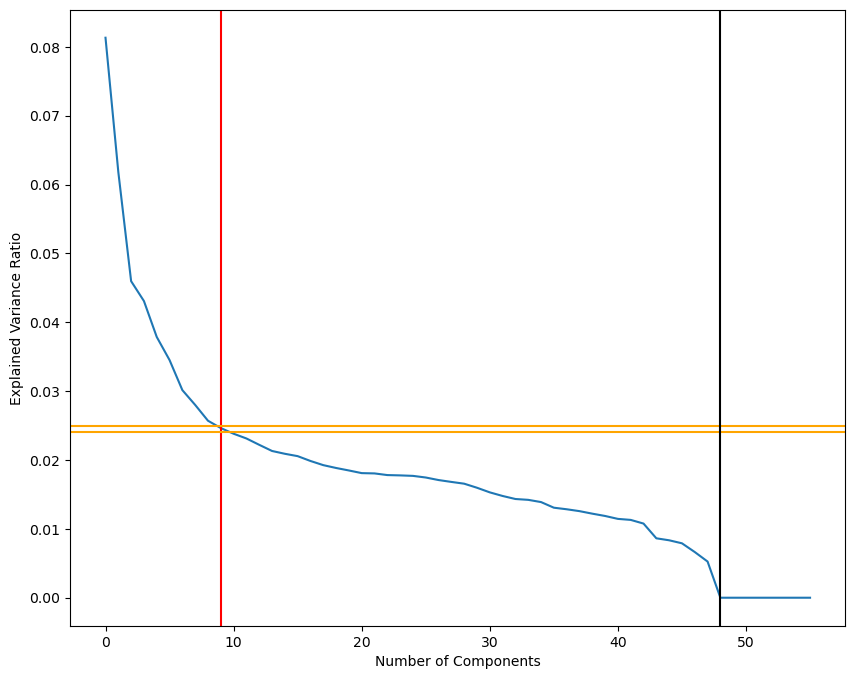

In [46]:
fig = plt.figure(figsize=(10,8))
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.axvline(x=9, c='red')
plt.axhline(y=0.024, c='orange')
plt.axhline(y=0.025, c='orange')
plt.axvline(x=48, c='black')
plt.show();

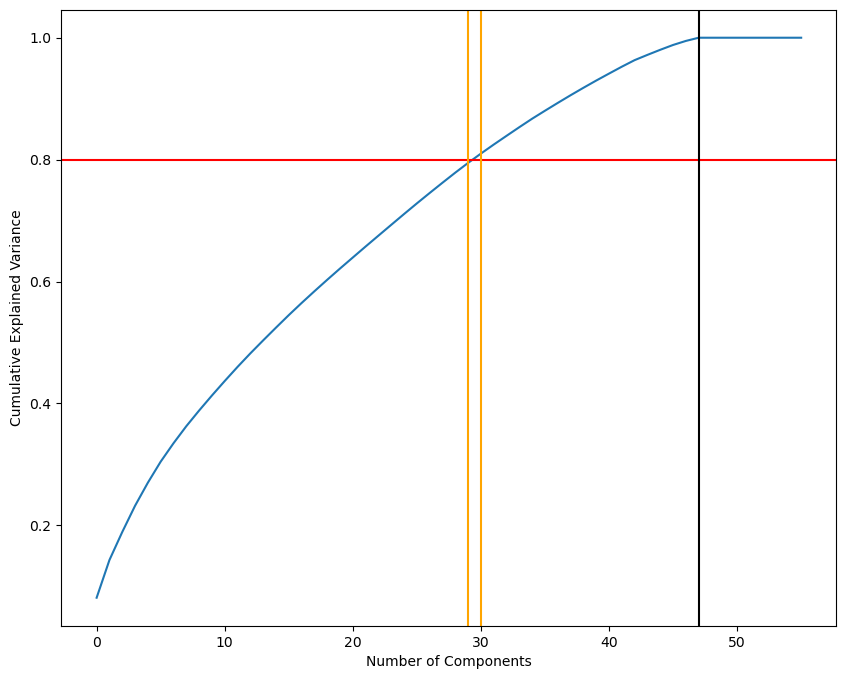

In [47]:
figure = plt.figure(figsize=(10,8))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.8, c='red')
plt.axvline(x=30, c='orange')
plt.axvline(x=29, c='orange')
plt.axvline(x=47, c='black')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show();

In [48]:
pca = PCA(n_components = 30)
df_pca = pca.fit_transform(df_scaled)

In [49]:
for pc in range(9):
    get_weights(pca, pc, col_list)

Top positive:
                          PC_1
voterstatus_Yes       0.288263
hetenure_Owned        0.248243
age_encoded           0.238677
donate_Yes            0.222722
news_encoded          0.214576
ntalk_encoded         0.210859
favors_encoded        0.193654
ffissues_encoded      0.185686
citizen_type_Citizen  0.183021
nissues_encoded       0.181499

Top negative:
                              PC_1
hetenure_Rented          -0.246878
voterstatus_No           -0.241210
pemaritl_NEVER MARRIED   -0.199078
citizen_type_Non         -0.182977
voterstatus_NA           -0.119668
hrnumhou                 -0.097121
work_status_Employed     -0.096499
simrace_Black            -0.077886
simrace_Asian            -0.075498
citizen_type_Naturalized -0.066802
----------------------------------------------------------
Top positive:
                              PC_2
work_status_Not Working   0.399650
age_encoded               0.294104
disability_Yes            0.282636
pemaritl_WIDOWED          0.2310

Let's tabulate this information to be easier to read:

| Component_Num | Positively-Pointed Features | Negatively-Pointed Features |
| ------------- | --------------------------- | --------------------------- |
| 1 | local voter, homeowner, age, donates non-politically, news consumption, interactions with neighbors, discusses issues with family/friends, native citizen | renter, inelligible or non-local voter, never married, non-citizen or naturalized, employed, black or asian, household size |
| 2 | Not working, age, disabled, widowed or divorced, lives in a mobile home, metro/non-metro, native citizen, non-local voter, southern | employed, income, education level, houshold size, lives in a house, married, discusses issues with family/friends, business owner, asian, participated in a boycott |
| 3 | citizen, divorced or never married, hispanic/non-hispanic, employed, renter, midwestern, metro/non-metro, participated in a boycott, black | asian or black, naturalized or non-citizen, married, asian, age, not working, inelligble to vote, homeowner, household size, western |
| 4 | homeowner, white, married, income, native citizen, household size, lives in a mobile home, metro/non-metro, non-local voter, midwestern | renter, interactions with neighbors, discusses issues with family/friends, black, takes action to improve community, shares views online, non-citizen, never married |
| 5 | lives in a house, hispanic/non-hispanic, education level, black or asian, local voter, age, not working, native citizen, disabled | lives in a mobile home, interactions with neighbors, white, non-citizen, takes action to improve community, metro/non-metro, household size, talks to family/friends |
| 6 | white, lives in a house, midwestern / western, renter, non-citizen, non-local or inelligible voter, participated in a boycott, disabled | black/asian/biracial, southern, lives in a mobile home, hispanic/non-hispanic, homeowner, local voter, education level, naturalized citizen |
| 7 | western, lives in a mobile home, local voter, participated in a boycott, donates politically, contacts politicians, divorced, belongs to organization(s), renter, education level | lives in a house, interactions with neighbors, non-local voter, southern, black, household size, takes action to improve community, talks to family/friends |
| 8 | non-local voter, asian or biracial, western or northeastern, naturalized citizen, hispanic/non-hispanic, talks to family/friends/neighbors, lives in a mobile home | southern, local or inelligible voter, non-citizen, white or black, lives in a house, married or seperated, renter |
| 9 | western, alaskan/american native / hawaiian/pacific islander / biracial, local voter, native citizen, never married, metro/non-metro, unemployed | northeastern or southern, divorced, non-local voter, naturalized citizen, employed, white, education level, donates non-politically, age |

### Clustering

In [50]:
clusters = range(2, 20)
inertias = {}
silhouette_scores = {}

for k in clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    
    # Store metrics
    inertias[k] = kmeans.inertia_
    score = silhouette_score(df_pca, kmeans.labels_)
    silhouette_scores[k] = score
    print(f"k={k} | Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {score:.3f}")

k=2 | Inertia: 1223628.82 | Silhouette Score: 0.146
k=3 | Inertia: 1150348.03 | Silhouette Score: 0.079
k=4 | Inertia: 1101321.93 | Silhouette Score: 0.069
k=5 | Inertia: 1050282.82 | Silhouette Score: 0.075
k=6 | Inertia: 1036287.44 | Silhouette Score: 0.070
k=7 | Inertia: 996934.48 | Silhouette Score: 0.070
k=8 | Inertia: 969397.23 | Silhouette Score: 0.071
k=9 | Inertia: 940659.60 | Silhouette Score: 0.074
k=10 | Inertia: 928334.78 | Silhouette Score: 0.071
k=11 | Inertia: 918802.64 | Silhouette Score: 0.077
k=12 | Inertia: 905245.68 | Silhouette Score: 0.073
k=13 | Inertia: 890208.95 | Silhouette Score: 0.073
k=14 | Inertia: 864065.44 | Silhouette Score: 0.081
k=15 | Inertia: 836154.22 | Silhouette Score: 0.085
k=16 | Inertia: 831549.65 | Silhouette Score: 0.078
k=17 | Inertia: 806442.27 | Silhouette Score: 0.083
k=18 | Inertia: 781778.61 | Silhouette Score: 0.088
k=19 | Inertia: 765325.43 | Silhouette Score: 0.090


In [51]:
score_diff = {}

for s in inertias.keys():
    try:
        score_diff[s] = inertias[s] - inertias[s+1]
    except KeyError:
        score_diff[s] = 0

In [52]:
inertia_lists = sorted(inertias.items())
sil_score_lists = sorted(silhouette_scores.items())
diff_lists = sorted(score_diff.items())

x1, y1 = zip(*inertia_lists)
x2, y2 = zip(*diff_lists)
x3, y3 = zip(*sil_score_lists)

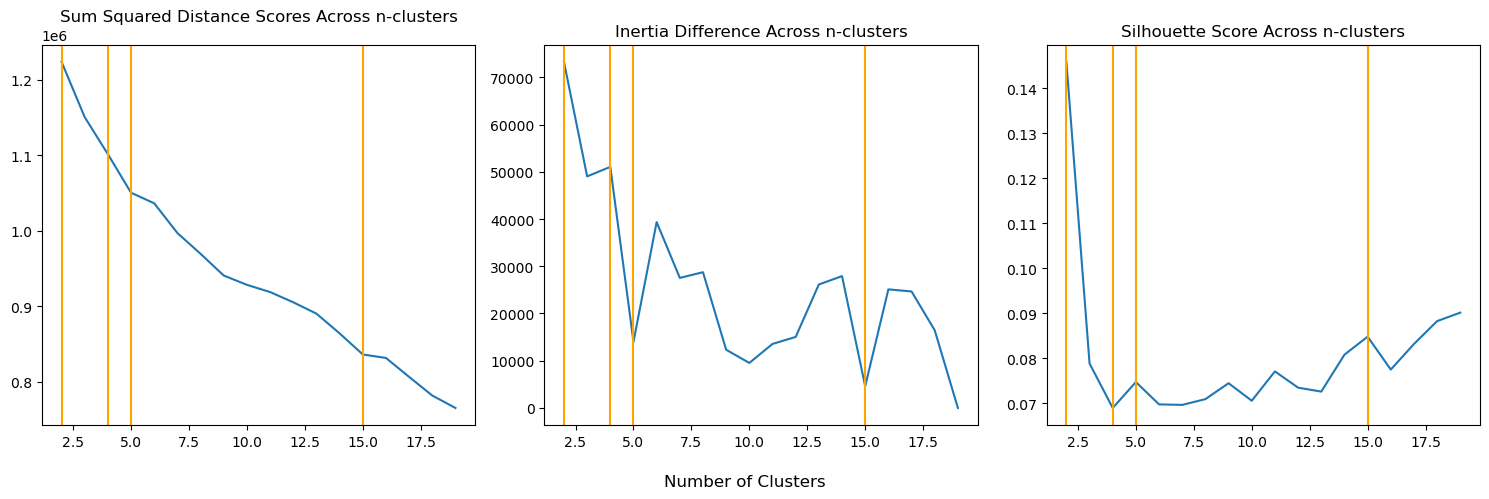

In [53]:
fig, (ax, bx, cx) = plt.subplots(1,3, figsize=(15,5))
fig.supxlabel('Number of Clusters')
ax.set_title('Sum Squared Distance Scores Across n-clusters')
bx.set_title('Inertia Difference Across n-clusters')
cx.set_title('Silhouette Score Across n-clusters')

ax.plot(x1, y1)
bx.plot(x2, y2)
cx.plot(x3, y3)

ax.axvline(x=2, c='orange')
ax.axvline(x=4, c='orange')
ax.axvline(x=5, c='orange')
ax.axvline(x=15, c='orange')

bx.axvline(x=2, c='orange')
bx.axvline(x=4, c='orange')
bx.axvline(x=5, c='orange')
bx.axvline(x=15, c='orange')

cx.axvline(x=2, c='orange')
cx.axvline(x=4, c='orange')
cx.axvline(x=5, c='orange')
cx.axvline(x=15, c='orange')

plt.tight_layout()
plt.show()

Slight elbow again at k=5, highest silhouette scores are on k=2 and 15 (ignoring k=18/19 as prior results show too much fragmentation of clusters). Including k=4 here to see if there is consistent portioning of clusters to the volunteer set, which could make for an interesting parallel analysis.

In [54]:
profile_col(df_nv, [2, 4, 5, 15])

k=2
cluster 1: 21.0%
cluster 2: 79.0%
-----------------------------
k=4
cluster 1: 19.2%
cluster 2: 19.7%
cluster 3: 36.1%
cluster 4: 25.1%
-----------------------------
k=5
cluster 1: 18.5%
cluster 2: 19.1%
cluster 3: 34.0%
cluster 4: 23.9%
cluster 5: 4.4%
-----------------------------
k=15
cluster 1: 8.9%
cluster 2: 11.9%
cluster 3: 15.3%
cluster 4: 11.4%
cluster 5: 4.6%
cluster 6: 6.4%
cluster 7: 4.0%
cluster 8: 2.0%
cluster 9: 0.1%
cluster 10: 6.6%
cluster 11: 4.4%
cluster 12: 7.4%
cluster 13: 7.3%
cluster 14: 9.3%
cluster 15: 0.3%
-----------------------------


k=15 is not desirable, it splits the clusters too finely to be meaningful.

k=2 is very lopsided towards cluster 2, so that is also less desirable.

k=4 or 5 I think could have merit, I want to inspect either case more before confirming a selection. Let's look at the centroids for each to see if their profiles tell different enough stories. 

In [55]:
km_model_4 = KMeans(n_clusters=4, random_state=42)
km_model_4.fit(df_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [56]:
centroids = km_model_4.cluster_centers_
centroids_scaled = pca.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_scaled, columns=col_list)

In [57]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=False).head(10)}\n")

cluster 1:
citizen_type_Naturalized    1.538428
citizen_type_Non            1.472342
simrace_Asian               1.137355
voterstatus_NA              0.976910
hrnumhou                    0.434791
hetenure_Rented             0.383067
pemaritl_MARRIED            0.244006
voterstatus_No              0.194735
work_status_Employed        0.176137
gereg_WEST                  0.176062
Name: 0, dtype: float64

cluster 2:
work_status_Not Working     1.044243
age_encoded                 0.914470
disability_Yes              0.666393
pemaritl_WIDOWED            0.592962
citizen_type_Citizen        0.364183
pehspnon_NON-HISPANIC       0.302729
veteran_Yes                 0.293101
gtmetsta_NONMETROPOLITAN    0.252254
hetenure_Owned              0.213723
pemaritl_DIVORCED           0.205151
Name: 1, dtype: float64

cluster 3:
pemaritl_NEVER MARRIED    0.821856
voterstatus_No            0.511937
hetenure_Rented           0.485863
work_status_Employed      0.468629
citizen_type_Citizen      0.367120
si

In [58]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=True).head(10)}\n")

cluster 1:
citizen_type_Citizen       -2.220899
pehspnon_NON-HISPANIC      -1.089985
voterstatus_Yes            -0.579359
simrace_White              -0.557585
gtmetsta_NONMETROPOLITAN   -0.437555
ed_level_encoded           -0.389043
hetenure_Owned             -0.372004
boycott_Yes                -0.309108
veteran_Yes                -0.304871
ffissues_encoded           -0.231133
Name: 0, dtype: float64

cluster 2:
work_status_Employed       -1.006336
hhincome_encoded           -0.557181
hrnumhou                   -0.489363
pemaritl_NEVER MARRIED     -0.414552
ed_level_encoded           -0.298102
hubus_YES                  -0.279687
citizen_type_Non           -0.266850
citizen_type_Naturalized   -0.227543
hetenure_Rented            -0.223053
simrace_Asian              -0.212189
Name: 1, dtype: float64

cluster 3:
age_encoded                -0.820202
pemaritl_MARRIED           -0.534634
work_status_Not Working    -0.514684
hetenure_Owned             -0.489817
voterstatus_Yes            -0

In [59]:
km_model_5 = KMeans(n_clusters=5, random_state=42)
km_model_5.fit(df_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [60]:
centroids = km_model_5.cluster_centers_
centroids_scaled = pca.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_scaled, columns=col_list)

In [61]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=False).head(10)}\n")

cluster 1:
citizen_type_Naturalized    1.564864
citizen_type_Non            1.444779
simrace_Asian               1.169337
voterstatus_NA              0.952745
hrnumhou                    0.422496
hetenure_Rented             0.384250
pemaritl_MARRIED            0.251324
housing_unit_House          0.232443
voterstatus_No              0.190016
work_status_Employed        0.173257
Name: 0, dtype: float64

cluster 2:
work_status_Not Working    1.063537
age_encoded                0.932537
disability_Yes             0.644924
pemaritl_WIDOWED           0.554595
citizen_type_Citizen       0.366226
veteran_Yes                0.317830
pehspnon_NON-HISPANIC      0.302805
hetenure_Owned             0.246038
housing_unit_House         0.237259
news_encoded               0.196735
Name: 1, dtype: float64

cluster 3:
pemaritl_NEVER MARRIED    0.850071
hetenure_Rented           0.539574
voterstatus_No            0.507759
work_status_Employed      0.443012
citizen_type_Citizen      0.363185
housing_unit

In [62]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=True).head(10)}\n")

cluster 1:
citizen_type_Citizen       -2.220613
pehspnon_NON-HISPANIC      -1.057687
simrace_White              -0.582536
voterstatus_Yes            -0.565126
gtmetsta_NONMETROPOLITAN   -0.457287
hetenure_Owned             -0.372250
ed_level_encoded           -0.344639
boycott_Yes                -0.304605
veteran_Yes                -0.300981
housing_unit_Mobile        -0.224106
Name: 0, dtype: float64

cluster 2:
work_status_Employed       -1.025133
hrnumhou                   -0.459889
hhincome_encoded           -0.450252
pemaritl_NEVER MARRIED     -0.432725
citizen_type_Non           -0.275430
hubus_YES                  -0.261736
hetenure_Rented            -0.252358
housing_unit_Mobile        -0.233411
citizen_type_Naturalized   -0.221929
ed_level_encoded           -0.206320
Name: 1, dtype: float64

cluster 3:
age_encoded                -0.815525
pemaritl_MARRIED           -0.567607
hetenure_Owned             -0.544022
work_status_Not Working    -0.489819
voterstatus_Yes            -0

These options seem pretty similar, the extra cluster when k=5, which holds 4.4% relevance within the nonvolunteer population, is extremely zoomed into housing type with a +4.15 value in the mobile home feature and -4.24 in the house feature. This makes me think it might just be pulling a very specific niche group from the other clusters, which isn't necessarily what I'm looking for. I will move forward with k=4.

In [63]:
km_model = KMeans(n_clusters=4, random_state=42)
nonvolunteers = km_model.fit_predict(df_pca)

In [64]:
df_nv['cluster'] = nonvolunteers

Let's bring back the profiling results to see how prevelant each cluster is in the volunteer population.

In [65]:
cluster_weights = df_nv.groupby('cluster')['supwgt'].sum()

In [66]:
cluster_share = cluster_weights / cluster_weights.sum()

In [67]:
cluster_labels = [1, 2, 3, 4]
cluster_colors = ['tab:red', 'tab:blue', 'tab:orange', 'tab:green']

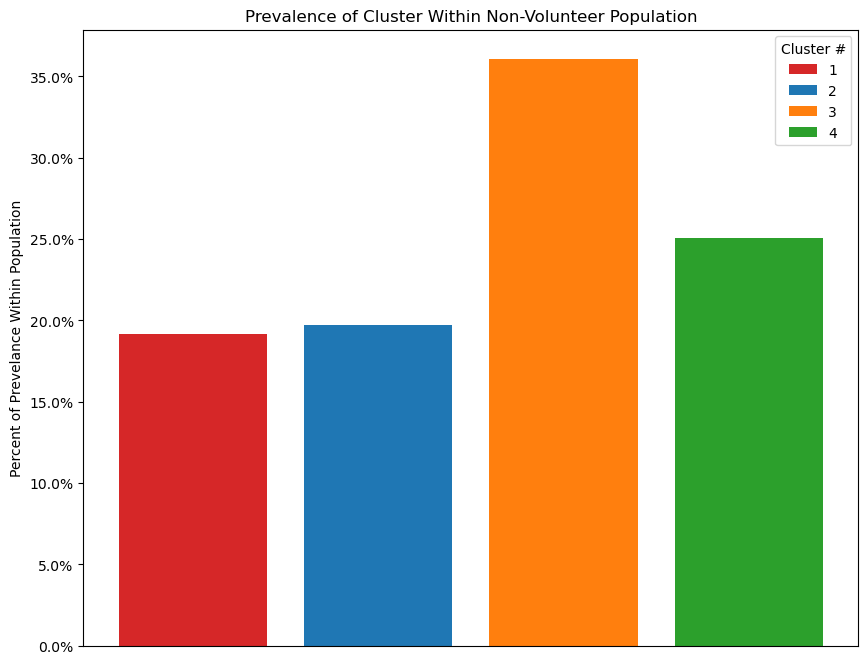

In [68]:
fig, ax = plt.subplots(figsize=(10,8))

ax.bar(cluster_labels, cluster_share, label=cluster_labels, color=cluster_colors)
ax.set_title('Prevalence of Cluster Within Non-Volunteer Population')
ax.set_ylabel('Percent of Prevelance Within Population')
ax.legend(title='Cluster #')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xticks([])

plt.show()

This shows that, using the provided nonresponse weight, in nonvolunteer population the traits that direct cluster 3 are most prevalent, and those in clusters 1, 2, and 4 are less prevalent but still sizable.

We already took a look at those features above, but as we move into analysis for this model's results we'll tabulate them.

### Analysis

Summarizing the above information:

| Cluster | Above-Average Features | Below-Average Features |
| ------------- | --------------------------- | --------------------------- |
| 1 | naturalized or non-citizen, asian, non-local or ineligble voter, household size, renter, employed, married, western | natural citizen, hispanic/non-hispanic, local voter, white, metro/non-metro, education level, homeowner, participated in a boycott, miltiary veteran, discusses issues with family/friends |
| 2 | not working, age, disabled, widowed or divorced, native citizen, hispanic/non-hispanic, veteran, metro/non-metro, homeowner | employed, income, household size, never married, education level, business owner, naturalized or non-citizen, renter, asian |
| 3 | never married, non-local voter, renter, employed or unemployed, native citizen, black / alaskan/american native / biracial, employed or unemployed, household size | age, married, not working, homeowner, local voter, news consumption, donates non-politically, talks and exchanges favors with neighbors, naturalized citizen |
| 4 | local voter, income, donates non-politically, education level, married, homeowner, discusses issues with family/friends, participated in a boycott, employed, news consumption | non-local or inelligble voter, renter, not working, widowed or never married, disabled, naturalized or non-citizen, black |

Similar to above, we will look cluster-by-cluster at the value statistics for the above-average features. 

A reminder that all individuals in this subset of data answered that they had not volunteered in some capacity in the last 12 months.

#### Cluster 1 Exploration

In [69]:
cluster_exp(df_nv, 0, centroids_df.iloc[0].sort_values(ascending=False).head(10).index)

citizen_type_Naturalized:

count    4101.000000
mean        0.486711
std         0.499884
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: citizen_type_Naturalized, dtype: float64


citizen_type_Naturalized
0    2105
1    1996
Name: count, dtype: int64
----------------------------------------------
citizen_type_Non:

count    4101.000000
mean        0.505243
std         0.500033
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: citizen_type_Non, dtype: float64


citizen_type_Non
1    2072
0    2029
Name: count, dtype: int64
----------------------------------------------
simrace_Asian:

count    4101.000000
mean        0.286515
std         0.452188
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: simrace_Asian, dtype: float64


simrace_Asian
0    2926
1    1175
Name: count, dtype: int64
------------------

Within this cluster, the above average outcomes show individuals that:

- Are 50/50 naturalized citizens or non-citizens,
- Are majority not solely Asian, 
- Do not vote locally or are otherwise inelligible to vote,
- Live in a household of 2-4 people,
- Are almost 50/50 rent / do not rent their home,
- Are majority married,
- Are majority employed, and
- Are majority not based in the West

This cluster is very logistical in focus, and it is centered on people born outside of the U.S. who are not native U.S. citizens though about half of them became citizens through naturalization, and they for the most part do not engage in local politics via voting. A curiosity for me here is that despite half of the population here being non-citizen, only 20% are marked as ineligible voters while 58% are marked as not participating which implies they are eligible. Upon looking into it more, there are certain local jurisdictions that permit non-citizens to participate in local elections - I'll be curious to see how the geographics line up on this cluster as these jurisdictions are mainly in the Northeast, with San Francisco being a sole jurisdiction in the West (Bush-Joseph, 2024). We can already see that a little over a third of the population here is based in the West. 

#### Cluster 2 Exploration

In [70]:
cluster_exp(df_nv, 1, centroids_df.iloc[1].sort_values(ascending=False).head(10).index)

work_status_Not Working:

count    8107.000000
mean        0.958061
std         0.200462
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: work_status_Not Working, dtype: float64


work_status_Not Working
1    7767
0     340
Name: count, dtype: int64
----------------------------------------------
age_encoded:

count    8107.000000
mean        6.119896
std         1.213638
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max         8.000000
Name: age_encoded, dtype: float64


age_encoded
6    2896
7    2275
5    1377
8     893
4     397
3     181
2      65
1      23
Name: count, dtype: int64
----------------------------------------------
disability_Yes:

count    8107.000000
mean        0.443937
std         0.496878
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: disability_Yes, dtype: float64


disability_Yes
0    4508
1    3599

Within this cluster, the above average outcomes show individuals that:

- Are not working,
- Are in their mid-60s or older,
- Are a little under 50/50 disabled or not,
- Are 40/60 on either being widowed / divorced or a different marriage status,
- Are native citizens,
- Are non-hispanic,
- Are not military veterans,
- Live primarily in metropolitan areas, and
- Tend to own their homes

Likely a cluster of suburban / urban retirees, pretty high rate of disability within the group. Not a ton to discern otherwise with the given features.

#### Cluster 3 Exploration

In [71]:
cluster_exp(df_nv, 2, centroids_df.iloc[2].sort_values(ascending=False).head(10).index)

pemaritl_NEVER MARRIED:

count    8661.000000
mean        0.614248
std         0.486801
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: pemaritl_NEVER MARRIED, dtype: float64


pemaritl_NEVER MARRIED
1    5320
0    3341
Name: count, dtype: int64
----------------------------------------------
hetenure_Rented:

count    8661.000000
mean        0.524651
std         0.499421
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: hetenure_Rented, dtype: float64


hetenure_Rented
1    4544
0    4117
Name: count, dtype: int64
----------------------------------------------
voterstatus_No:

count    8661.000000
mean        0.729015
std         0.444494
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: voterstatus_No, dtype: float64


voterstatus_No
1    6314
0    2347
Name: count, dtype: int64
------------------------

Within this cluster, the above average outcomes show individuals that:

- Have majority never married,
- Tend not to vote in local elections,
- Are employed,
- Are citizens,
- Are not solely Black, solely Alaskan / American Native, or Biracial 
- Live either alone or with another person

These are working citizens that either live alone or with a roomate / partner since they tend to have never married, who do not get involved in local politics. I would guess that this is a younger cohort, will be interested to see how the other features shape up.

#### Cluster 4 Exploration

In [72]:
cluster_exp(df_nv, 3, centroids_df.iloc[3].sort_values(ascending=False).head(10).index)

hhincome_encoded:

count    8309.000000
mean        3.640510
std         1.171151
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: hhincome_encoded, dtype: float64


hhincome_encoded
5    2607
3    2232
4    1940
2    1228
1     302
Name: count, dtype: int64
----------------------------------------------
voterstatus_Yes:

count    8309.000000
mean        0.817307
std         0.386438
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: voterstatus_Yes, dtype: float64


voterstatus_Yes
1    6791
0    1518
Name: count, dtype: int64
----------------------------------------------
ed_level_encoded:

count    8309.000000
mean       10.754724
std         2.135293
min         0.000000
25%         9.000000
50%        12.000000
75%        12.000000
max        15.000000
Name: ed_level_encoded, dtype: float64


ed_level_encoded
12    2539
8     1673
9     1217
13    1188
11     6

Within this cluster, the above average outcomes show individuals that:

- Vote in local elections,
- Are at least middle-class, with a large portion that are upper class,
- Tend to make non-political donations,
- Have received higher education,
- Are married,
- Own their homes,
- Discuss political, societal, or local issues with their friends or family very frequently,
- Typically have not participated in a boycott,
- Are employed, and
- Consume news about political, societal, or local issues very frequently

These folks are educated, highly engaged with and informed on issues, have higher levels of income, are pretty civically involved, and yet they have not volunteered recently.

### Conclusion

Referring back to those prevelance statistics:
```
cluster 1: 19.2%
cluster 2: 19.7%
cluster 3: 36.1%
cluster 4: 25.1%
```

Our most prevalent cluster is primarily unmarried, working people that aren't engaged in local politics, and our second most prevalent cluster is primarily middle-to-upper class, married, working, homeowners that keep up with issues and vote locally. These two clusters seem opposed, yet they share the fact that neither group has been volunteering lately. I want to see the full feature spread for them individually.

In [73]:
df_nv[df_nv['cluster'] == 2].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            9.155178
fftalk_encoded              4.000693
age_encoded                 2.691722
hhincome_encoded            2.639187
hrnumhou                    2.620598
news_encoded                2.581919
ffissues_encoded            1.572682
ntalk_encoded               1.296848
citizen_type_Citizen        0.999423
housing_unit_House          0.945156
pehspnon_NON-HISPANIC       0.839741
work_status_Employed        0.784090
simrace_White               0.748528
voterstatus_No              0.729015
favors_encoded              0.670130
pemaritl_NEVER MARRIED      0.614248
pesex_MALE                  0.526729
hetenure_Rented             0.524651
hetenure_Owned              0.459069
gereg_SOUTH                 0.393719
views_encoded               0.352038
nissues_encoded             0.264635
gereg_WEST                  0.263826
voterstatus_Yes             0.244429
pemaritl_MARRIED            0.239118
gereg_MIDWEST               0.220875
donate_Yes                  0.215218
g

As I suspected, this is a younger group of people (avg. age in the 25-34 bracket) who are in a lower-middle class income bracket and have probably attended college but either not yet graduated or dropeed out. They are fairly evenly split between owning or renting the houses they live in, and the only civic engagement metric they score highly on is talking with family or friends, with news about issues being something they do more occasionally. They live in metropolitan areas, more typically in the South (39%), and are primarily non-Hispanic White. The lack of civic engagement activity in the general sense makes their non-volunteer status make sense. These are probably people who are in transition from early adulthood and keeping their heads down, working and surviving.

In [74]:
df_nv[df_nv['cluster'] == 3].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            10.754724
age_encoded                  4.415935
fftalk_encoded               4.396317
news_encoded                 4.149717
hhincome_encoded             3.640510
ffissues_encoded             2.844145
ntalk_encoded                2.655675
hrnumhou                     2.529306
favors_encoded               1.722710
nissues_encoded              1.084487
housing_unit_House           0.986160
citizen_type_Citizen         0.980984
pehspnon_NON-HISPANIC        0.945481
simrace_White                0.915393
hetenure_Owned               0.914310
voterstatus_Yes              0.817307
pemaritl_MARRIED             0.773739
work_status_Employed         0.755927
donate_Yes                   0.685401
views_encoded                0.552172
pesex_MALE                   0.531472
gereg_SOUTH                  0.326513
boycott_Yes                  0.312071
gereg_WEST                   0.272957
org_Yes                      0.254303
action_Yes                   0.236250
work_status_

Slightly more educated on average than the previous cluster, roughly 20 years their senior, with more income. They talk to their friends and families about what they've seen on the news, a little more than half will go on to share their views online, but interestingly are not similarly engaged with their neighbors. A good chunk do indirect civic engagement via non-political donations, but are much lower on direct civic engagement items like exchanging favors with neighbors, contacting public officials, going to public meetings, participating in community benefit activities, or joining organizations. They do vote in local elections, live in metropolitan areas, and are primarily non-hispanic White.

Next I want to look at the first cluster, the non-U.S. borne folks.

In [75]:
df_nv[df_nv['cluster'] == 0].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            8.627652
fftalk_encoded              4.017801
age_encoded                 3.947574
news_encoded                2.947574
hrnumhou                    2.934162
hhincome_encoded            2.658376
ntalk_encoded               1.670568
ffissues_encoded            1.554255
housing_unit_House          0.961717
favors_encoded              0.876859
work_status_Employed        0.626920
pemaritl_MARRIED            0.619849
simrace_White               0.594245
voterstatus_No              0.587662
hetenure_Owned              0.523775
pehspnon_NON-HISPANIC       0.511826
citizen_type_Non            0.505243
citizen_type_Naturalized    0.486711
pesex_MALE                  0.482809
hetenure_Rented             0.466228
nissues_encoded             0.419898
gereg_WEST                  0.360644
work_status_Not Working     0.352109
gereg_SOUTH                 0.347232
views_encoded               0.304316
donate_Yes                  0.295294
simrace_Asian               0.286515
p

We do see a big dip in the amount of people who are White (still the majority at 59%), and a big increase in the amount of people who are Asian (29%); this is also a group that is pretty much 50/50 on the hispanic indicator, which has not been seen yet. The West region is also the most prevalent, which historically has large Asian and Hispanic populations - given the earlier confusion around voting eligibility in local elections for non-citizens, I think it's fair to say there's a good chunk of San Franciscans in this cluster.

As for other, more broad traits describing this cluster: they tend to be in their early 40s, have at least a high school level education, talk with friends and family frequently but not really about issues, don't engage much with their neighbors, keep up with the news somewhat, about 50/50 on renting or owning the house they live in, sit in a lower-middle class income bracket, and almost entirely live in metropolitan areas. Civic engagement metrics are quite low for this group, they seem more family-focused. Perhaps there is also less incentive for this group to engage civically given they almost entirely are not from the U.S., even if 49% have gone through the process of naturalizing.

In [76]:
df_nv[df_nv['cluster'] == 1].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            8.754656
age_encoded                 6.119896
fftalk_encoded              4.013692
news_encoded                3.724929
ntalk_encoded               2.315160
hhincome_encoded            2.021586
hrnumhou                    1.797952
ffissues_encoded            1.682497
favors_encoded              1.234242
citizen_type_Citizen        0.983841
work_status_Not Working     0.958061
pehspnon_NON-HISPANIC       0.950783
housing_unit_House          0.905144
simrace_White               0.854323
hetenure_Owned              0.785864
nissues_encoded             0.629703
voterstatus_Yes             0.527939
voterstatus_No              0.461330
pemaritl_MARRIED            0.446774
disability_Yes              0.443937
gereg_SOUTH                 0.437030
pesex_MALE                  0.419144
donate_Yes                  0.412483
gtmetsta_NONMETROPOLITAN    0.290736
pemaritl_WIDOWED            0.251758
views_encoded               0.233009
gereg_WEST                  0.210435
p

These folks are non-hispanic White, in their mid 60s (average start of retirement years), hold high school level educations, and are pretty squarely in the lower-middle class bracket with 95% of people not working. They tend towards living alone or with a spouse, own their metropolitan house (20% rent), have a significant population of people with a disability (44%), and live largely in the South (44%). Almost 10% of people live in a mobile home rather than a house, almost 30% live in non-metropolitan areas. They talk with family and friends often, neighbors sometimes, but almost never about issues; they are almost 50/50 on participating in local elections despite 99% of them being eligible to do so; there's a fair amount on non-political donation happening, but other forms of civic engagement are harder to come by. This feels like there are accessibility issues at play, especially given the large amount of people dealing with disability, the higher rate of rural living, and the tendency to be more isolated (this and the older-pop cluster from the volunteer set are the only clusters where the average household size is <1)

# Conclusion

We found four clusters within each of the volunteer and non-volunteer sets, each with pretty diverse results:

- In the volunteer set, the most population-prevalent clusters 1 (26%) and 4 (34%) shared some characteristics surrounding base demographics (upper-middle class income, non-hispanic White, 35-44 age bracket) and family composition, but differed greatly when it came to civic engagement participations. The other clusters were opposed on age range, but showed a general tendency towards higher civic engagement overall. Common characteristics across the clusters included being college educated to at least the Associate's degree level, being citizens, and being family-oriented.
- In the non-volunteer set, all of the clusters were quite different. The most population-prevalent clusters 3 (36%) and 4 (25%) were almost opposites feature-wise: mostly unmarried vs. married, opted out of local voting vs. engaged heavily in local elections, 50/50 owning houses vs. almost all owning houses. Similar to the volunteer set, one cluster centered on an older population, this time with way less civic engagement activity and much higher disability and rural-living. There was also a cluster centered pretty much entirely on people born outside of the U.S. with no native citizenship, which I believe would show a fairly high number of people living in San Francisco if that level of geographic granularity were retained. Common threads across all the clusters were being highly connected to family, and having comparatively lower education levels (somewhere between high school graduate and Associate's degree).

# References

1. Bush-Joseph, K. (2024, September). <i>Explainer: Noncitizen voting in U.S. elections.</i> Migration Policy Institute. https://www.migrationpolicy.org/content/noncitizen-voting-us-elections 